# Lotka-Volterra equation: additional loss and updated monitoring

This notebook is a toy example to showcase the additional feature of this fork: a per-loss-component tracking and an updated monitoring feature to display the differental equation solution, the residual and the component losses in separated plots.</br>
For the case study we consider the Lotka-Volterra equation, frequently used to describe the dynamics of biological systems in which two species interact, one as a predator and the other as prey, with an additional loss term to soft-enforce a population constraint.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent 
sys.path.append(str(ROOT.parent)) 

In [2]:
from neurodiffeq.neurodiffeq import diff
from neurodiffeq.neurodiffeq.solvers import Solver1D, Solver2D
from neurodiffeq.neurodiffeq.conditions import IVP, DirichletBVP2D
from neurodiffeq.neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.neurodiffeq.monitors import Monitor1D
import numpy as np
import torch
%matplotlib widget
import matplotlib.pyplot as plt
plt.ion()

We implement a 1-dimensional solver with an additional loss method implemented, that measures the deviation of the prey+predator population from a target value.

In [4]:
class PopulationConstraintSolver(Solver1D):
    def additional_loss(self, residuals, funcs, batch):
        u, v = funcs
        total = u + v
        target = 2.5
        return ((total - target) ** 2).mean()

Fitting the solver shows how the additional loss term is tracked in the history logs of the solver, and plot by the monitor (both the training and validation loss): this is basic implementation of a fundamental debugging feature when dealing with a loss function with multiple terms, to detect imbalances or silent failure:

Training Progress:   0%|                               | 0/3000 [00:00<?, ?it/s]

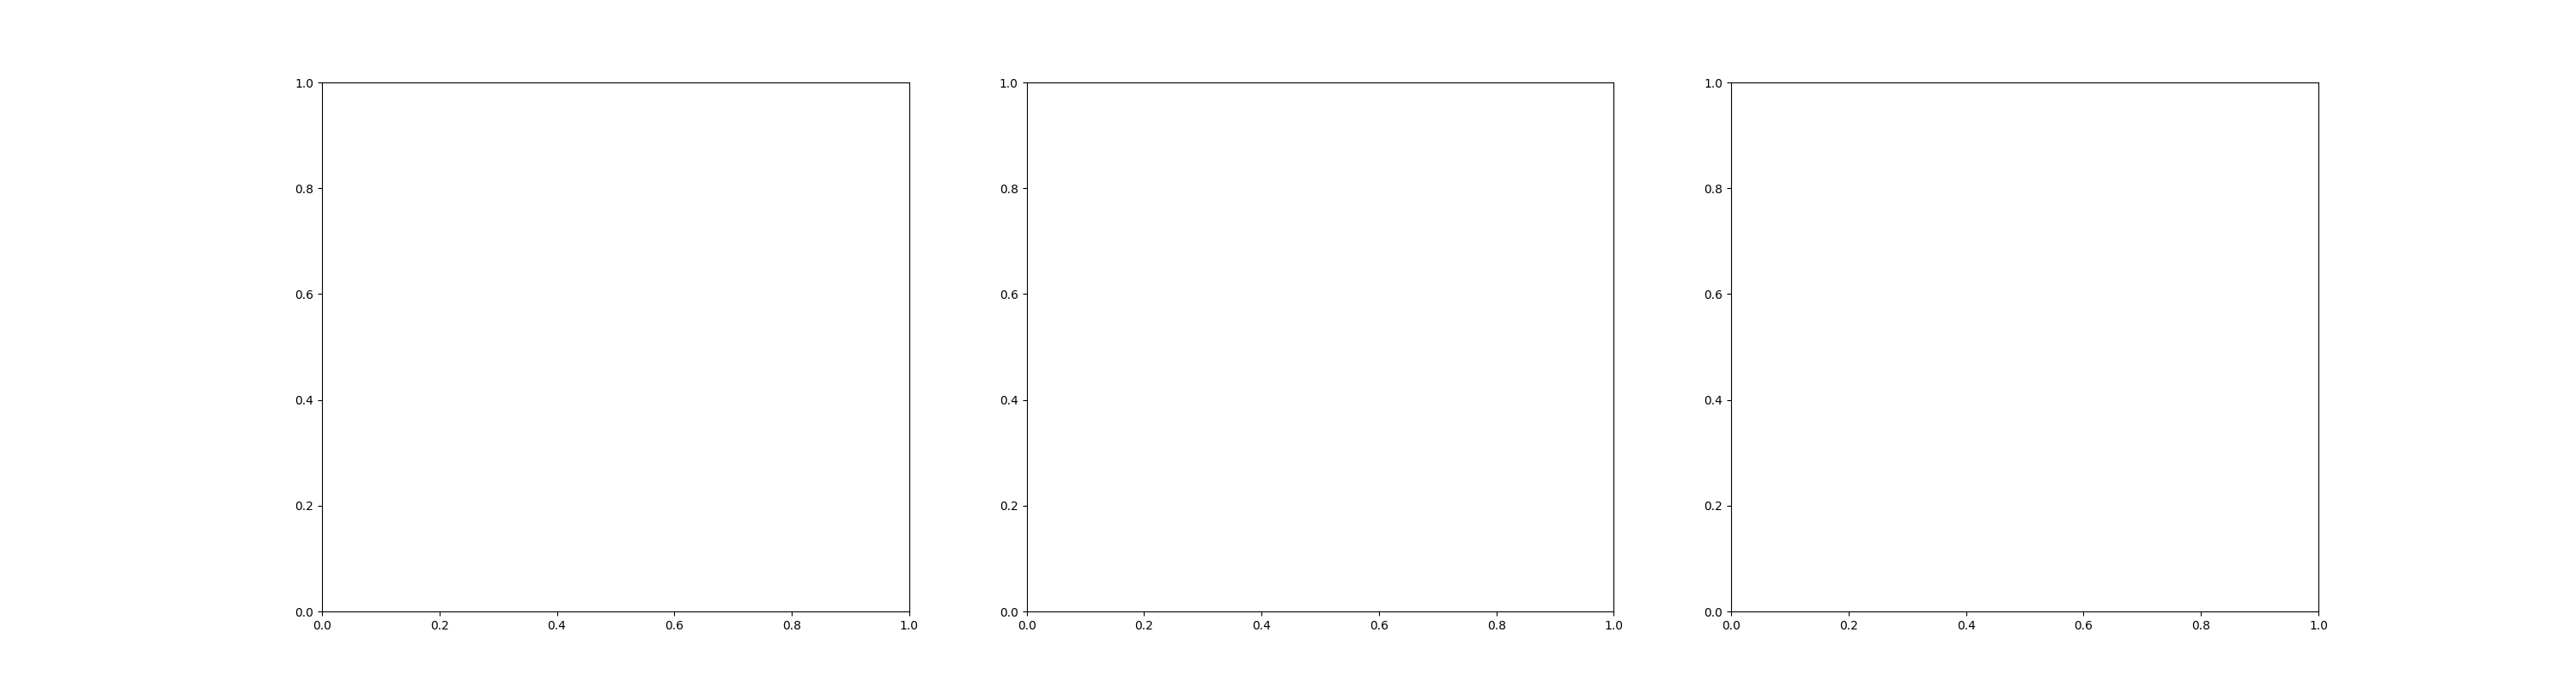

In [5]:
def ode_system(u, v, t): 
    return [diff(u,t)-(u-u*v), diff(v,t)-(u*v-v)]

conditions = [IVP(t_0=0.0, u_0=1.5), IVP(t_0=0.0, u_0=1.0)]
nets = [FCNN(actv=SinActv), FCNN(actv=SinActv)]

solver = PopulationConstraintSolver(ode_system, conditions, t_min=0.1, t_max=12.0, nets=nets, track_loss_components=True)
monitor = Monitor1D(t_min=0.0, t_max=12.0, check_every=100)
solver.fit(max_epochs=3000, callbacks=[monitor.to_callback()])
solution = solver.get_solution()